# Extracción de metadatos de estudios
Este notebook lee imágenes de diferentes estudios y extrae sus respectivos metadatos para exportarlos en un archivo de Excel

Elaborado por Juan Manuel Rivera/AJS

# Importación de librerías y funciones auxiliares

In [ ]:
import os
import SimpleITK as sitk
import numpy as np
import pandas as pd
import ast
import matplotlib.pyplot as plt
import json
import seaborn as sns

En la siguiente celda está la dirección del directorio donde están las imágenes

In [22]:
paths = [
    ("AISD","D:/jm.rivera/nnUnet_data/nnUNet_raw/Dataset001_AISD"),
    ("ISLES", "D:/jm.rivera/nnUnet_data/nnUNet_raw/Dataset003_ISLES"),
    ("APIS", "D:/jm.rivera/nnUnet_data/nnUNet_raw/Dataset005_APIS"),
    ("FSFB","D:/jm.rivera/nnUnet_data/nnUNet_raw/Dataset007_FSFB1C")
    ]

# Extracción de metadatos

Si desea añadir algún metadato añada el DICOM Tag en la siguiente lista

In [23]:
tags = {
    #DB
    "db" : [],
    # File path
    "file_path" : [],
    # Mean z-spacing
    "spacing" : [],
    # Number of slices
    "size" : [],
    # Lesion total size
    "lesion_size":[],
    # Number of conected lesions
    "connected_components" : [],
    # Mean component size
    "connected_size" : [],
    # SD component size
    "connected_sd" : [],
    "connected_sizes" : []
}

In [24]:
for datasets in paths:
    for img_path in os.listdir(os.path.join(datasets[1], "labelsTr")):
        seg = os.path.join(datasets[1], "labelsTr",img_path)
        vol = os.path.join(datasets[1], "imagesTr",f"{img_path[:-7]}_0000{img_path[-7:]}")

        original_img = sitk.ReadImage(vol)
        seg_img = sitk.ReadImage(seg)

        seg_array = sitk.GetArrayFromImage(seg_img)

        cc = sitk.ConnectedComponent(seg_img, True)
        stats = sitk.LabelShapeStatisticsImageFilter()
        stats.Execute(cc)

        spacing = original_img.GetSpacing()
        voxel_volume = spacing[0] * spacing[1] * spacing[2]

        for tag, array in tags.items():
            if tag == "db":
                array.append(datasets[0])
            if tag == 'file_path':
                array.append(img_path)
            elif tag == 'spacing':
                array.append(spacing)
            elif tag == 'size':
                array.append(original_img.GetSize())
            elif tag == 'lesion_size':
                array.append( np.count_nonzero(seg_array)*voxel_volume)
            elif tag == "connected_components":
                array.append(stats.GetNumberOfLabels())
            elif tag == "connected_sizes" or tag == "connected_size" or tag == "connected_sd":
                sizes = [stats.GetNumberOfPixels(label) * voxel_volume for label in stats.GetLabels()]
                if len(sizes) == 0:
                    array.append(0)
                else:
                    sizes = np.array(sizes)
                    if tag == "connected_size":
                        array.append(sizes.mean())
                    elif tag == "connected_sd":
                        array.append(sizes.std())
                    else:
                        array.append(sizes)

In [25]:
df = pd.DataFrame(data=tags)
display(df.head(5))

,db,file_path,spacing,size,lesion_size,connected_components,connected_size,connected_sd,connected_sizes
0,AISD,AISD_001.nii.gz,"(0.4375, 0.4375, 8.0)","(512, 512, 17)",29231.562500,1,29231.562500,0.000000,[29231.5625]
1,AISD,AISD_002.nii.gz,"(0.4296875, 0.4296875, 9.26413345336914)","(512, 512, 16)",7823.595759,9,869.288418,1208.832648,"[259.98831554315984, 424.19146220199764, 95.78..."
2,AISD,AISD_003.nii.gz,"(0.404296875, 0.404296875, 3.0044877529144287)","(512, 512, 42)",23663.231755,3,7887.743918,10617.222990,"[22902.515625450655, 455.25103430455147, 305.4..."
3,AISD,AISD_004.nii.gz,"(0.50390625, 0.50390625, 9.002614974975586)","(512, 512, 14)",3972.994270,1,3972.994270,0.000000,[3972.994269682502]
4,AISD,AISD_005.nii.gz,"(0.4375, 0.4375, 8.0)","(512, 512, 19)",30957.281250,8,3869.660156,7135.597950,"[940.1875, 499.1875, 22388.40625, 4694.8125, 6..."


In [26]:
df.describe()

,lesion_size,connected_components,connected_size,connected_sd
count,771.000000,771.000000,771.000000,771.000000
mean,34593.924121,5.382620,15528.647938,9050.230444
std,57563.943929,7.466299,40518.727195,20105.536433
min,0.000000,0.000000,0.000000,0.000000
25%,3555.062218,1.000000,772.214583,0.000000
50%,12874.815958,3.000000,2973.915257,1562.752862
75%,38628.838516,6.000000,11269.120602,7557.147819
max,384269.705347,84.000000,384269.705347,163920.748904


In [27]:
df.to_excel("MetadatosNIfTI.xlsx")

# Análisis de metadatos

In [69]:
df=pd.read_excel("MetadatosNIfTI.xlsx")

In [70]:
df["spacing"] = df["spacing"].apply(ast.literal_eval)
df["size"] = df["size"].apply(ast.literal_eval)

In [72]:
df[df['db'] == 'FSFB']

,db,file_path,spacing,size,lesion_size,connected_components,connected_size,connected_sd,connected_sizes
602,FSFB,FSFB_001.nii.gz,"(0.4492189884185791, 0.4492189884185791, 4.999...","(512, 512, 27)",10440.663473,2,5220.331736,5042.755705,[10263.08744164 177.57603124]
603,FSFB,FSFB_002.nii.gz,"(0.4882810115814209, 0.4882810115814209, 4.999...","(512, 512, 28)",18286.193620,2,9143.096810,8090.508220,[ 1052.58858972 17233.60503017]
604,FSFB,FSFB_003.nii.gz,"(0.4882810115814209, 0.4882810115814209, 4.999...","(512, 512, 28)",42961.211222,1,42961.211222,0.000000,[42961.21122203]
605,FSFB,FSFB_004.nii.gz,"(0.4882810115814209, 0.4882810115814209, 4.999...","(512, 512, 28)",35822.464926,2,17911.232463,529.833483,[17381.39898007 18441.06594573]
606,FSFB,FSFB_005.nii.gz,"(0.3984380066394806, 0.3984380066394806, 5.000...","(512, 512, 28)",498.530950,1,498.530950,0.000000,[498.53094993]
...,...,...,...,...,...,...,...,...,...
766,FSFB,FSFB_165.nii.gz,"(0.46875, 0.46875, 4.999627113342285)","(512, 512, 28)",12358.697393,1,12358.697393,0.000000,[12358.69739321]
767,FSFB,FSFB_166.nii.gz,"(0.46875, 0.46875, 5.154026031494141)","(512, 512, 22)",482.434956,1,482.434956,0.000000,[482.43495617]
768,FSFB,FSFB_167.nii.gz,"(0.46875, 0.46875, 4.999879837036133)","(512, 512, 32)",1665.487317,2,832.743658,774.517519,[1607.26117711 58.2261397 ]
769,FSFB,FSFB_168.nii.gz,"(0.43945300579071045, 0.43945300579071045, 5.0...","(512, 512, 28)",0.000000,0,0.000000,0.000000,0


In [12]:
df.groupby('db')['connected_components'].describe()

,count,mean,std,min,25%,50%,75%,max
db,,,,,,,,
AISD,397.0,5.156171,4.486320,0.0,2.0,4.0,6.0,28.0
APIS,59.0,2.338983,2.623568,0.0,1.0,1.0,2.5,13.0
FSFB,169.0,1.130178,1.227503,0.0,0.0,1.0,2.0,9.0
ISLES,146.0,12.150685,12.862853,1.0,4.0,8.0,15.0,84.0


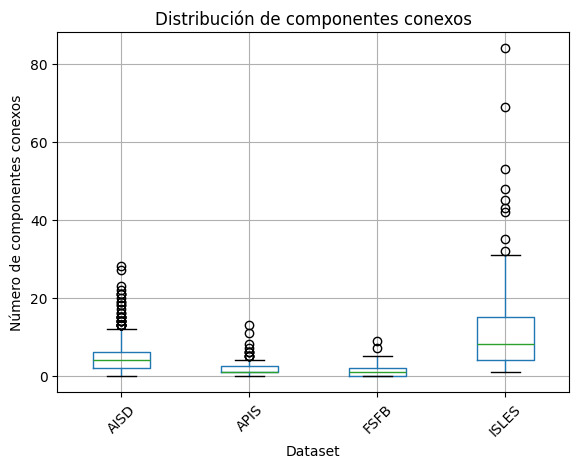

In [18]:
df.boxplot(column="connected_components", by="db")

plt.title("Distribución de componentes conexos")
plt.suptitle("")
plt.xlabel("Dataset")
plt.ylabel("Número de componentes conexos")
plt.xticks(rotation=45)
plt.show()

In [26]:
df["connected_components"] = df["connected_components"].apply(int)
df[(df['db'] == 'FSFB') & (df['connected_components']>2)][['file_path','connected_components']]

,file_path,connected_components
620,FSFB_019.nii.gz,3
631,FSFB_030.nii.gz,3
645,FSFB_044.nii.gz,7
647,FSFB_046.nii.gz,3
650,FSFB_049.nii.gz,5
666,FSFB_065.nii.gz,3
694,FSFB_093.nii.gz,3
695,FSFB_094.nii.gz,3
727,FSFB_126.nii.gz,3
731,FSFB_130.nii.gz,3


In [13]:
df["z_spacing"] = df["spacing"].apply(lambda x: x[2])

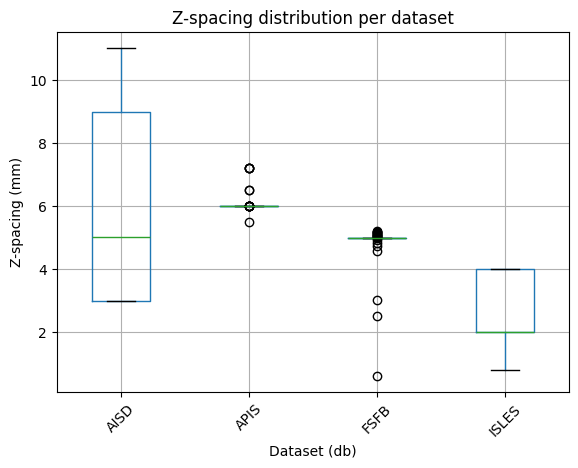

In [17]:
df.boxplot(column="z_spacing", by="db")

plt.title("Z-spacing distribution per dataset")
plt.suptitle("")  # removes automatic title
plt.xlabel("Dataset (db)")
plt.ylabel("Z-spacing (mm)")
plt.xticks(rotation=45)
plt.show()

In [29]:
with open("summary.json", "r") as f:
    data = json.load(f)

rows = []

for case in data["metric_per_case"]:
    dice = case["metrics"]["1"]["Dice"]
    pred_path = case["prediction_file"]
    filename = os.path.basename(pred_path)

    rows.append({
        "file": filename,
        "dice": dice
    })

dice_scores = pd.DataFrame(rows)

In [30]:
dice_scores

,file,dice
0,FSFB_003.nii.gz,0.520229
1,FSFB_011.nii.gz,0.685515
2,FSFB_017.nii.gz,NaN
3,FSFB_018.nii.gz,0.226982
4,FSFB_021.nii.gz,0.658868
5,FSFB_025.nii.gz,0.000000
6,FSFB_034.nii.gz,0.758724
7,FSFB_036.nii.gz,0.735647
8,FSFB_040.nii.gz,0.717145
9,FSFB_041.nii.gz,NaN


In [ ]:
df = pd.merge(df, dice_scores, left_on='file_path', right_on='file')
df.head(5)

In [37]:
df_clean = df.dropna(subset=["dice"]).copy()

In [41]:
df_clean.columns

Index(['db', 'file_path', 'spacing', 'size', 'lesion_size',
       'connected_components', 'connected_size', 'connected_sd',
       'connected_sizes', 'file', 'dice'],
      dtype='object')

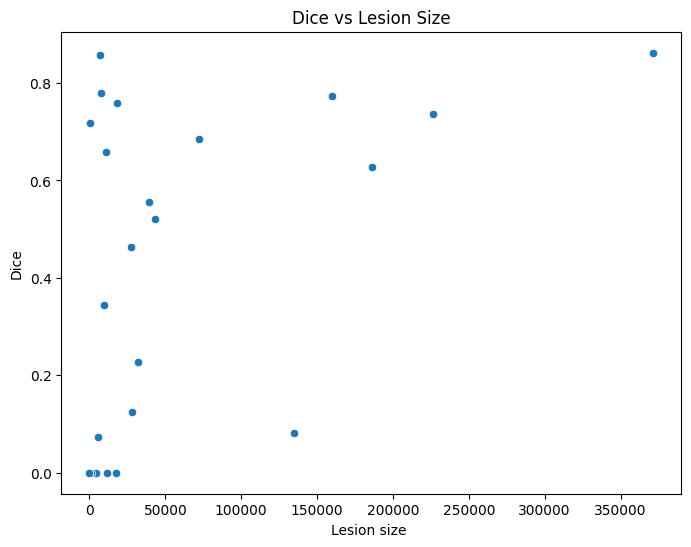

In [44]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_clean,
    x="lesion_size",
    y="dice"
)

#plt.xscale("log")
plt.xlabel("Lesion size ")
plt.ylabel("Dice")
plt.title("Dice vs Lesion Size")

plt.show()

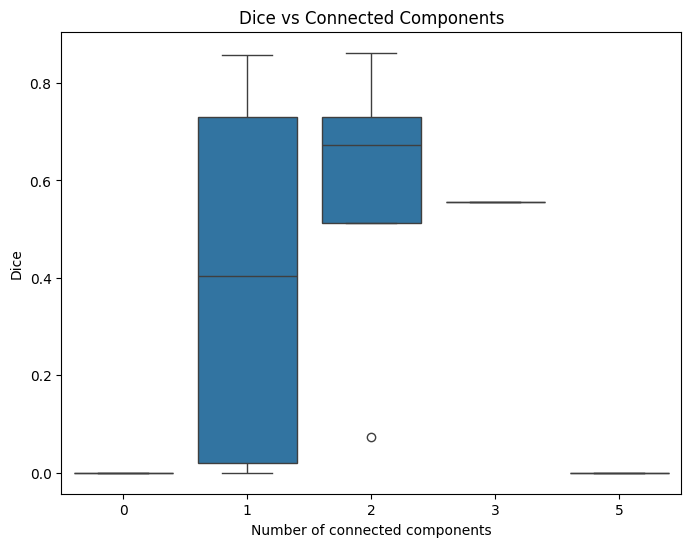

In [42]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df_clean,
    x="connected_components",
    y="dice"
)

plt.xlabel("Number of connected components")
plt.ylabel("Dice")
plt.title("Dice vs Connected Components")

plt.show()

# Métricas de sobrelapamiento por componente conexo

In [65]:
def compute_gt_detection(gt_path, pred_path):
    gt = sitk.ReadImage(gt_path)
    gt_bin = gt > 0
    pred = sitk.ReadImage(pred_path)

    pred_array = sitk.GetArrayFromImage(pred) > 0

    # GT connected components
    cc_gt = sitk.ConnectedComponent(gt_bin)
    cc_array = sitk.GetArrayFromImage(cc_gt)
    
    stats = sitk.LabelShapeStatisticsImageFilter()
    stats.Execute(cc_gt)

    detected_count = 0
    total = 0

    for label in stats.GetLabels():
        gt_comp = (cc_array == label)

        intersection = np.logical_and(gt_comp, pred_array).sum()

        if intersection > 0:
            detected_count += 1

        total += 1

    detection_rate = detected_count / total if total > 0 else np.nan

    return detected_count, total, detection_rate

In [66]:
results = []

for _, row in df_clean.iterrows():
    filename = row["file_path"]

    gt_path = f"C:/Users/jmriv/Dataset006_FSFB/labelsTr/{filename}"

    pred_path = f"C:/Users/jmriv/Documents/FSFB/validation/{filename}"

    detected, total, rate = compute_gt_detection(gt_path, pred_path)

    results.append({
        "file": filename,
        "gt_lesions": total,
        "detected_lesions": detected,
        "detection_rate": rate
    })

In [67]:
df_detection = pd.DataFrame(results)

In [68]:
df_detection

,file,gt_lesions,detected_lesions,detection_rate
0,FSFB_003.nii.gz,1,1,1.000000
1,FSFB_011.nii.gz,4,1,0.250000
2,FSFB_018.nii.gz,1,1,1.000000
3,FSFB_021.nii.gz,2,1,0.500000
4,FSFB_025.nii.gz,1,0,0.000000
5,FSFB_034.nii.gz,1,1,1.000000
6,FSFB_036.nii.gz,1,1,1.000000
7,FSFB_040.nii.gz,1,1,1.000000
8,FSFB_043.nii.gz,1,1,1.000000
9,FSFB_049.nii.gz,5,0,0.000000


In [58]:
df_detection.describe()

,gt_lesions,detected_lesions,detection_rate
count,27.000000,27.000000,24.000000
mean,1.407407,0.740741,0.663194
std,1.152231,0.594371,0.439916
min,0.000000,0.000000,0.000000
25%,1.000000,0.000000,0.187500
50%,1.000000,1.000000,1.000000
75%,1.500000,1.000000,1.000000
max,5.000000,2.000000,1.000000


In [ ]:
gt = sitk.ReadImage(f"C:/Users/jmriv/Dataset006_FSFB/labelsTr/{}")
pred = sitk.ReadImage(f"C:/Users/jmriv/OneDrive - Universidad de los andes/Appremia - Proyecto Maestría/FSFB/validation/{}")

cc = sitk.ConnectedComponent(gt)

stats = sitk.LabelShapeStatisticsImageFilter()
stats.Execute(cc)

gt_array = sitk.GetArrayFromImage(gt) > 0
pred_array = sitk.GetArrayFromImage(pred) > 0
cc_array = sitk.GetArrayFromImage(cc)

results = []

for label in stats.GetLabels():
    gt_comp = (cc_array == label)

    intersection = np.logical_and(gt_comp, pred_array).sum()
    gt_size = gt_comp.sum()
    pred_in_comp = np.logical_and(pred_array, gt_comp).sum()

    # Metrics
    recall = intersection / gt_size if gt_size > 0 else 0
    detected = intersection > 0

    results.append({
        "label": label,
        "gt_size": gt_size,
        "intersection": intersection,
        "recall": recall,
        "detected": detected
    })

In [ ]:
import numpy as np

gt_array = sitk.GetArrayFromImage(gt) > 0
pred_array = sitk.GetArrayFromImage(pred) > 0
cc_array = sitk.GetArrayFromImage(cc)

results = []

for label in stats.GetLabels():
    gt_comp = (cc_array == label)

    intersection = np.logical_and(gt_comp, pred_array).sum()
    gt_size = gt_comp.sum()
    pred_in_comp = np.logical_and(pred_array, gt_comp).sum()

    # Metrics
    recall = intersection / gt_size if gt_size > 0 else 0
    detected = intersection > 0

    results.append({
        "label": label,
        "gt_size": gt_size,
        "intersection": intersection,
        "recall": recall,
        "detected": detected
    })

# Inspección de componentes conexos

In [ ]:
seg = os.path.join(datasets[1], "labelsTr",img_path)
vol = os.path.join(datasets[1], "imagesTr",f"{img_path[:-7]}_0000{img_path[-7:]}")

original_img = sitk.ReadImage(vol)
seg_img = sitk.ReadImage(seg)

seg_array = sitk.GetArrayFromImage(seg_img)

cc = sitk.ConnectedComponent(seg_img, True)
stats = sitk.LabelShapeStatisticsImageFilter()
stats.Execute(cc)

import SimpleITK as sitk

num_labels = stats.GetNumberOfLabels()

component_masks = []

for label in stats.GetLabels():
    component = sitk.BinaryThreshold(cc,
                                     lowerThreshold=label,
                                     upperThreshold=label)
    component_masks.append(component)